In [ ]:
import numpy as np
import torch as th
import time, json, sys, os
import argparse
from PIL import Image

parser = argparse.ArgumentParser()
# parser.add_argument('--set_', default='train')
# parser.add_argument('--sample_json', required=True)
# parser.add_argument('--rasterize_type', default='standard')
# parser.add_argument('--n_frames', type=int, required=True)
# args = parser.parse_args()
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

n_frames = 20
set_ = 'valid'
sample_json = '/home/mint/Dev/DiFaReli/difareli-faster/eval_request/sumit.json'
rasterize_type = 'standard'
import misc
deca_params, avg_dict = misc.load_deca_params(deca_dir=f'/data/mint/DPM_Dataset/eval_request/Sumit/params/{set_}', cfg=None)


Loading deca params...: 100%|██████████| 10/10 [00:00<00:00, 269.70it/s]


In [3]:
print(deca_params.keys())
print(deca_params['input.png'])

dict_keys(['input.png', 'output.png'])
{'shadow': array([0.7272945]), 'shape': array([ 3.41657100e-01, -2.37980600e-02,  2.03395170e-01,  1.03541700e-01,
        2.52656200e-02,  3.95065620e-02,  3.15715760e-01,  3.93187460e-01,
       -3.58228100e-01,  9.49709000e-02,  1.45652890e-03,  4.44462750e-01,
        5.14005530e-02,  4.23308460e-03,  6.92676700e-02,  3.60584100e-02,
       -2.02980820e-01, -3.14498480e-01, -3.10078000e-02, -6.57854300e-01,
        2.48733970e-01,  3.10871540e-01, -2.59446860e-01,  2.73589280e-01,
       -1.94210650e-01, -5.13600700e-02, -1.55192970e-01, -5.18826900e-01,
        5.38908240e-01,  1.80978280e-01,  1.65756400e-01, -1.76367490e-01,
        1.00837690e-01, -1.24398210e-01, -2.69077840e-01, -1.97838050e-01,
       -2.47130200e-01, -5.20202460e-01, -1.42805220e-01, -3.28600400e-04,
       -3.11301600e-01,  2.48840270e-01, -5.00354800e-01, -6.48142800e-01,
        6.39614460e-01, -2.00491010e-01,  2.45751460e-01,  3.29155300e-01,
       -4.60259200e-0

In [4]:
sys.path.append("/home/mint/Dev/DiFaReli/difareli-faster/sample_scripts/sample_utils/")
import mani_utils, params_utils
start_t = time.time()
mask = params_utils.load_flame_mask()
deca_obj = params_utils.init_deca(mask=mask, rasterize_type=rasterize_type)
print(f"[#] Time taken to load DECA: {time.time()-start_t}")

# with open(sample_json) as f:
#     gen_shadow = json.load(f)['pair']

# Load params

creating the FLAME Decoder
USING STARDARD...
/home/mint/Dev/DiFaReli/difareli-faster/sample_scripts/cond_utils/DECA/decalib/utils
[#] DECA : SRenderY applied mask
[#] Time taken to load DECA: 21.718092679977417


In [5]:
# Load the DeCA model
# sj = '4085.jpg'
sj = 'input.png'
rotate_sh_axis = 2
n_step = n_frames
src_idx = 0
cond = deca_params[sj].copy()
render_batch_size = 20
render_mode = 'shape'
rotate_normals = False
# cond = {k: cond[k] for k in keys}
for k in cond.keys():
    cond[k] = th.tensor(cond[k][None, ...])
# cond['raw_image_path'] = ['/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/train/' + sj]
cond['raw_image_path'] = ['/data/mint/DPM_Dataset/eval_request/Sumit/images_aligned/valid/' + sj]
cond['raw_image'] = th.tensor(np.array(Image.open(cond['raw_image_path'][0]))).permute(2, 0, 1)[None, ...]

print(cond['light'].shape)
# interp_cond = mani_utils.rotate_sh(cond, src_idx=src_idx, n_step=n_step, axis=rotate_sh_axis)
interp_cond = {'light':mani_utils.interp_cond(cond['light'], deca_params['output.png']['light'], n_step, interp_fn=mani_utils.lerp)}
sub_step = mani_utils.ext_sub_step(n_step, render_batch_size)
cond['light'] = interp_cond['light']

for i in range(len(sub_step)-1):
    start = sub_step[i]
    end = sub_step[i+1]
    sub_cond = cond.copy()
    sub_cond['light'] = sub_cond['light'][start:end, :]
    # Deca rendered : B x 3 x H x W
    deca_rendered, orig_visdict = params_utils.render_deca(deca_params=sub_cond, 
                                                        idx=0, n=end-start, 
                                                        avg_dict=avg_dict, 
                                                        render_mode=render_mode, 
                                                        rotate_normals=rotate_normals, 
                                                        mask=mask,
                                                        deca_obj=deca_obj,
                                                        repeat=True)
    

torch.Size([1, 27])
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([20, 3, 256, 256])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1.1544396
0.0


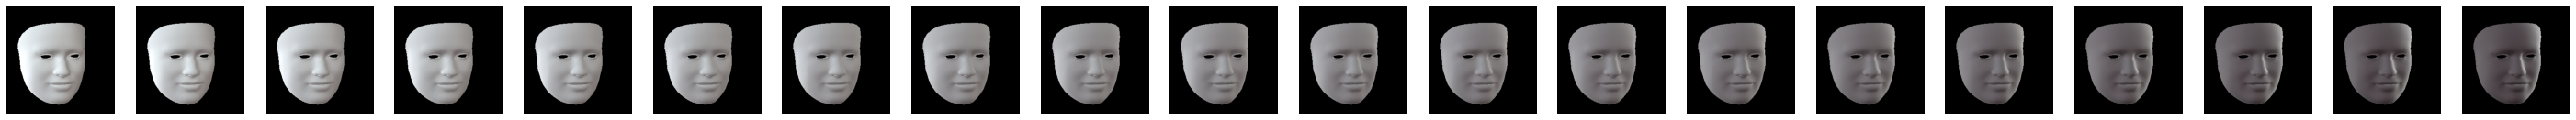

In [6]:
print(deca_rendered.shape)
deca_rendered = deca_rendered.cpu().numpy()
# Vis all images
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, n_frames, figsize=(50, 50))
for i in range(n_frames):
    axs[i].imshow(deca_rendered[i].transpose(1, 2, 0))
    axs[i].axis('off')

# Save as video with torchvision
import torchvision.io as tvio
print(deca_rendered.max())
print(deca_rendered.min())
tvio.write_video('deca_rendered.mp4', np.clip(deca_rendered.transpose(0, 2, 3, 1) * 255, 0, 255), 30)


# Render with any SH from Sumit

In [32]:
import imp
imp.reload(misc)
import copy
def render(sh, out='deca_rendered'):
    # interp_cond = mani_utils.rotate_sh(cond, src_idx=src_idx, n_step=n_step, axis=rotate_sh_axis)
    interp_cond = {'light':mani_utils.interp_cond(cond['light'], sh, n_step, interp_fn=mani_utils.lerp)}
    sub_step = mani_utils.ext_sub_step(n_step, render_batch_size)
    cond_mod = cond.copy()
    cond_mod['light'] = copy.deepcopy(interp_cond['light'])

    for i in range(len(sub_step)-1):
        start = sub_step[i]
        end = sub_step[i+1]
        sub_cond = cond_mod.copy()
        sub_cond['light'] = sub_cond['light'][start:end, :]
        # Deca rendered : B x 3 x H x W
        deca_rendered, orig_visdict = params_utils.render_deca(deca_params=sub_cond, 
                                                            idx=0, n=end-start, 
                                                            avg_dict=avg_dict, 
                                                            render_mode=render_mode, 
                                                            rotate_normals=rotate_normals, 
                                                            mask=mask,
                                                            deca_obj=deca_obj,
                                                            repeat=True)
        ball_rendered = []
        for l in range(sub_cond['light'].shape[0]):
            ball_rendered.append(misc.drawSphere(sh=th.tensor(sub_cond['light'][l]).view(9, 3)))
        ball_rendered = np.stack(ball_rendered, 0)
        print("DECA: ", deca_rendered.shape)
        print("BALL: ", ball_rendered.shape)
        deca_rendered = deca_rendered.cpu().numpy()
        # Vis all images
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, n_frames, figsize=(25, 25))
        for i in range(n_frames):
            axs[i].imshow(np.clip(deca_rendered[i], 0, 1.0).transpose(1, 2, 0))
            axs[i].axis('off')
        plt.show()
        fig, axs = plt.subplots(1, n_frames, figsize=(25, 25))
        for i in range(n_frames):
            axs[i].imshow(ball_rendered[i].transpose(1, 2, 0))
            axs[i].axis('off')
        plt.show()

        # Save as video with torchvision
        import torchvision.io as tvio
        print(deca_rendered.max())
        print(deca_rendered.min())
        tvio.write_video(f'./{out}.mp4', np.clip(deca_rendered.transpose(0, 2, 3, 1) * 255, 0, 255), 30)
        return deca_rendered

assert False
import pickle
for fn in ['./difareli_test/sh_ldr.pkl', './difareli_test/sh_norm.pkl', './difareli_test/sh_raw.pkl']:
    with open(fn, 'rb') as f:
        sh_load_npy = pickle.load(f)
        print(sh_load_npy, sh_load_npy.shape)
        sh_load = th.tensor(sh_load_npy).transpose(1, 0)
        # sh_load[0, :] *= 10
        # sh_load *= 15
        print(sh_load, sh_load.shape)
        # sh_load = sh_load / np.linalg.norm(sh_load, axis=1, keepdims=True)
        print(sh_load, sh_load.shape)
        sh_load = sh_load.flatten()[None, ...]
        print(sh_load, sh_load.shape)
        # sh_load = th.tensor(sh_load_npy).flatten()[None, ...]
        cc = misc.toRGBCoeff(sh_load.flatten().squeeze(0).cpu().numpy())
        sh_load = misc.toRGBDeca(cc)
        sh_load = np.array(sh_load)[None, ...]
        
    # Load the DeCA model
    # sj = '4085.jpg'
    sj = 'input.png'
    rotate_sh_axis = 2
    n_frames = 5
    n_step = n_frames
    src_idx = 0
    cond = deca_params[sj].copy()
    render_batch_size = 5
    render_mode = 'shape'
    rotate_normals = False
    # cond = {k: cond[k] for k in keys}
    for k in cond.keys():
        cond[k] = th.tensor(cond[k][None, ...])
    cond['raw_image_path'] = ['/data/mint/DPM_Dataset/eval_request/Sumit/images_aligned/valid/' + sj]
    cond['raw_image'] = th.tensor(np.array(Image.open(cond['raw_image_path'][0]))).permute(2, 0, 1)[None, ...]

    print(cond['light'].shape)
        
    render(sh_load, fn.split('/')[-1].split('.')[0])

render(deca_params['output.png']['light'], 'output_light')

AssertionError: 

(20, 9, 3)
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


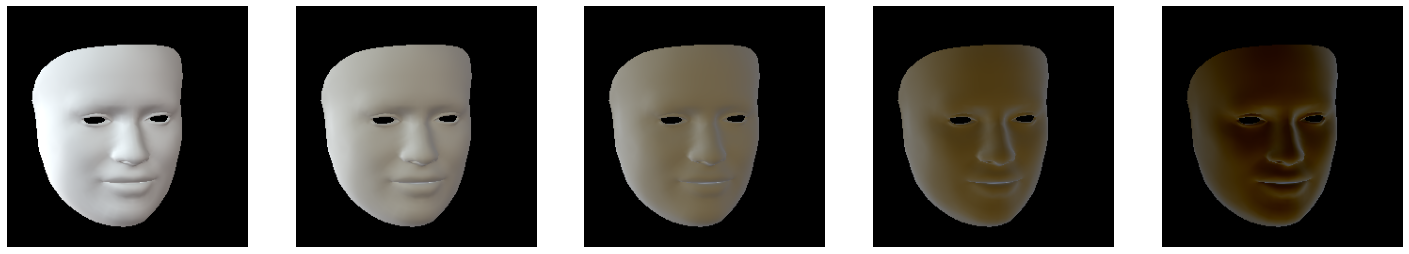

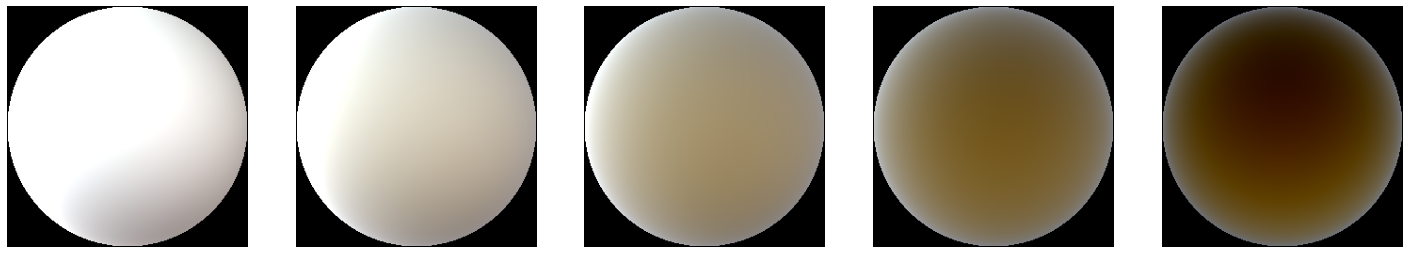

1.1544397
-0.15441337


In [10]:
roll_sh = np.load('./difareli_test/roll_l2.npy')
print(roll_sh.shape)
# for i in range(roll_sh.shape[0]):
render(roll_sh[10].flatten()[None, ...], f'roll_{i}')

[[ 1.6133097   1.683767    1.85105099]
 [-0.11539696 -0.0790766  -0.0131041 ]
 [ 0.24661423  0.3985419   0.71988154]
 [-0.01993272 -0.02418854 -0.01487283]
 [ 0.17492573  0.15976004  0.12323653]
 [-0.15668625 -0.13183002 -0.08639733]
 [-0.21265283 -0.19278027 -0.11031229]
 [-0.08685047 -0.07658826 -0.05020383]
 [ 0.03211916  0.0137769  -0.00696749]]
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


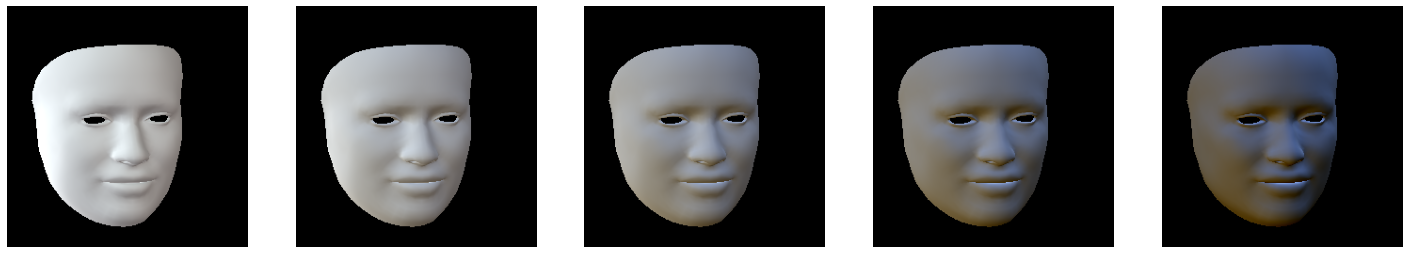

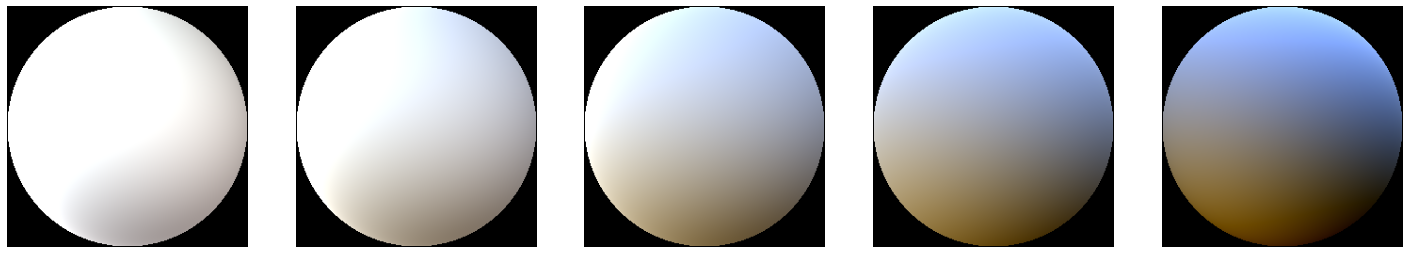

1.1544397
-0.13706388
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


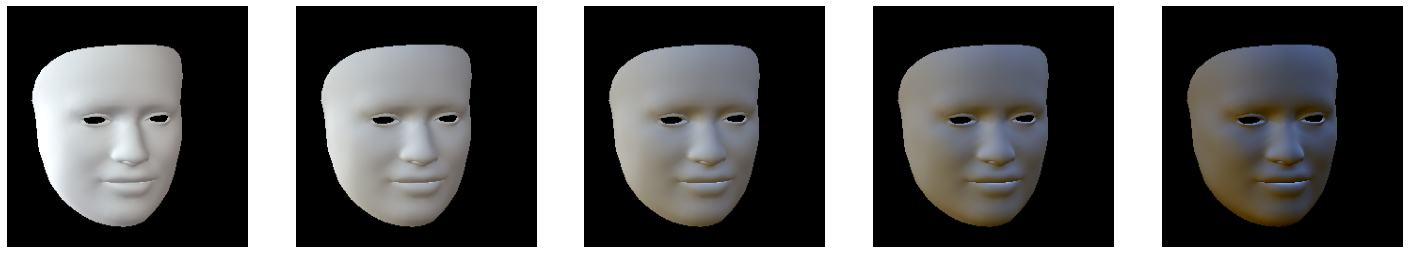

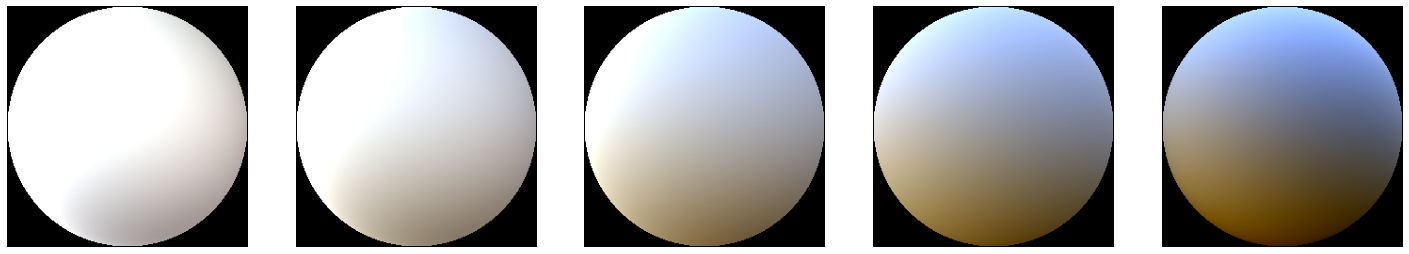

1.1544397
-0.13592419
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


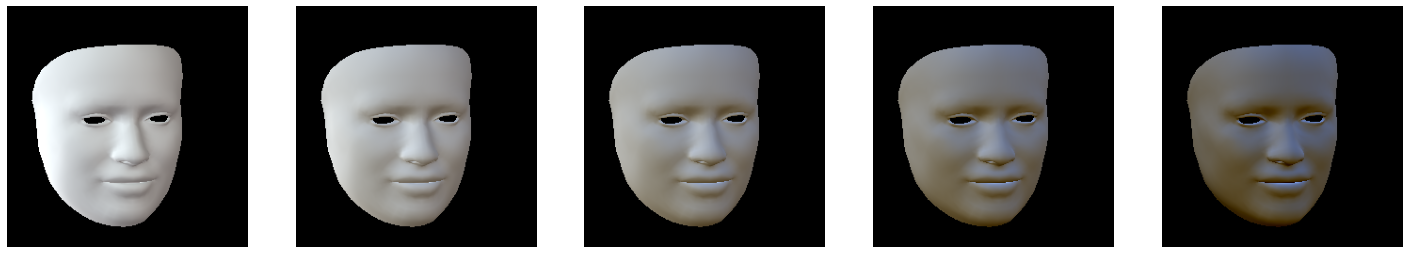

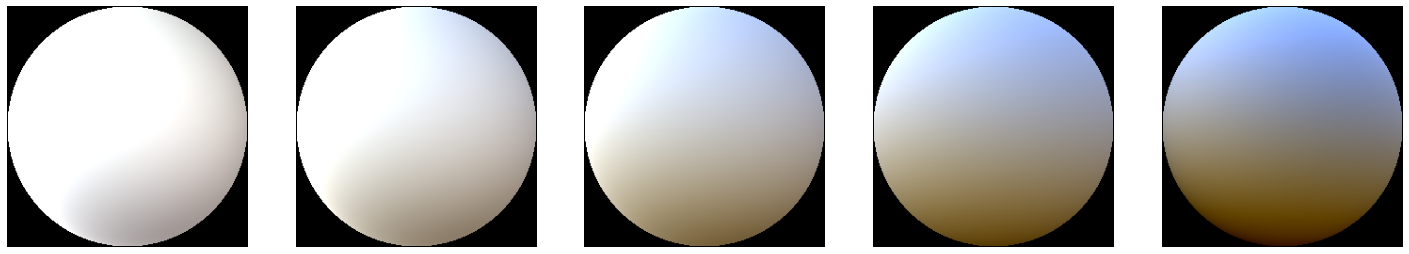

1.1544397
-0.17006657
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


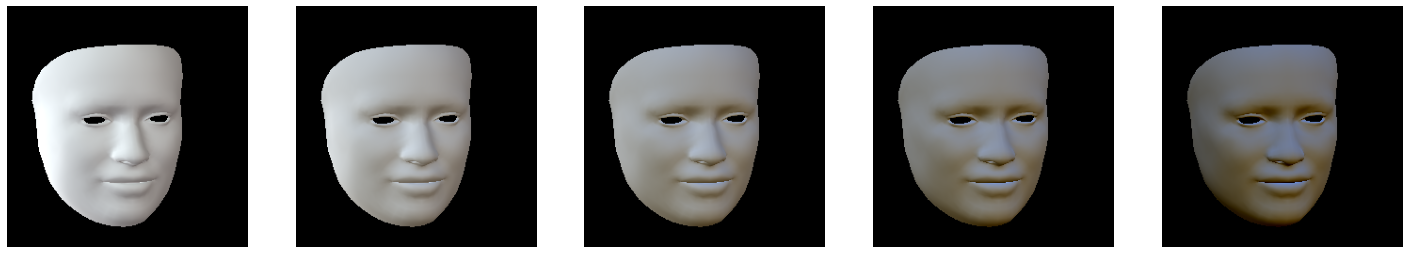

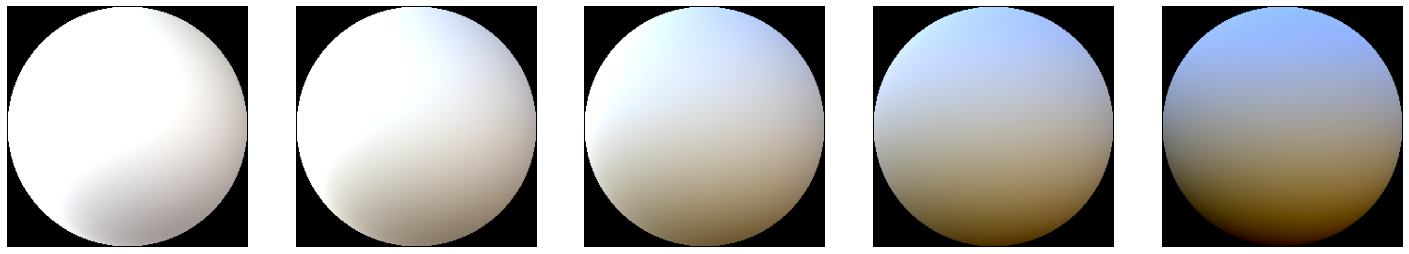

1.1544397
-0.20140927
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


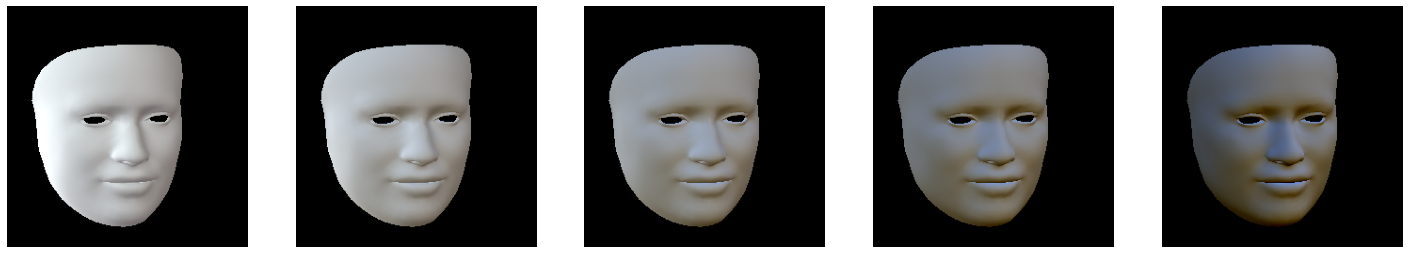

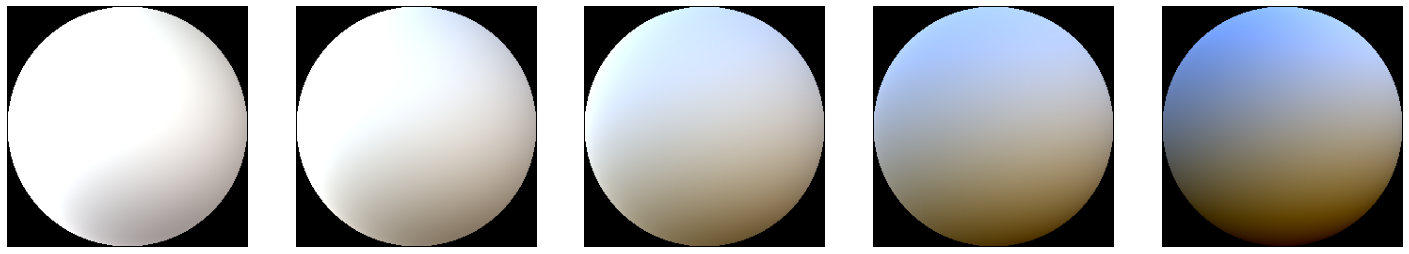

1.1544397
-0.1887866
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


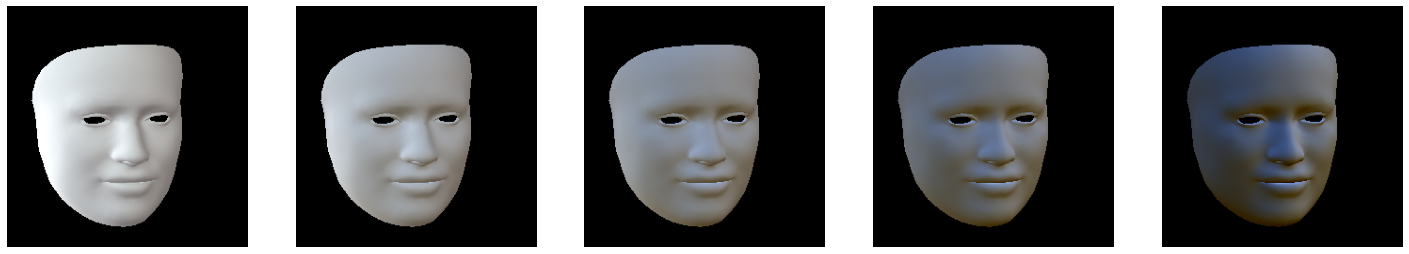

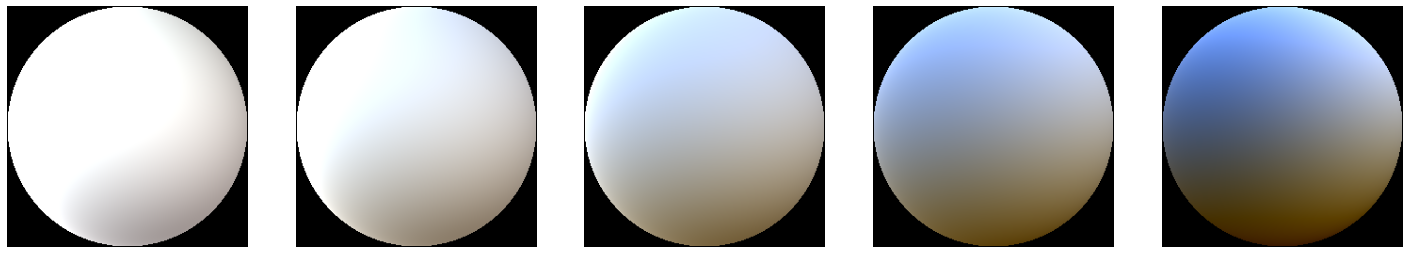

1.1544397
-0.14352147
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


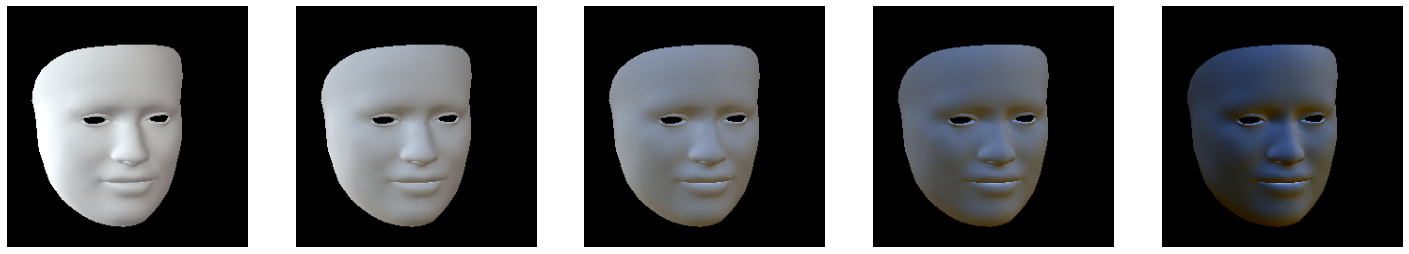

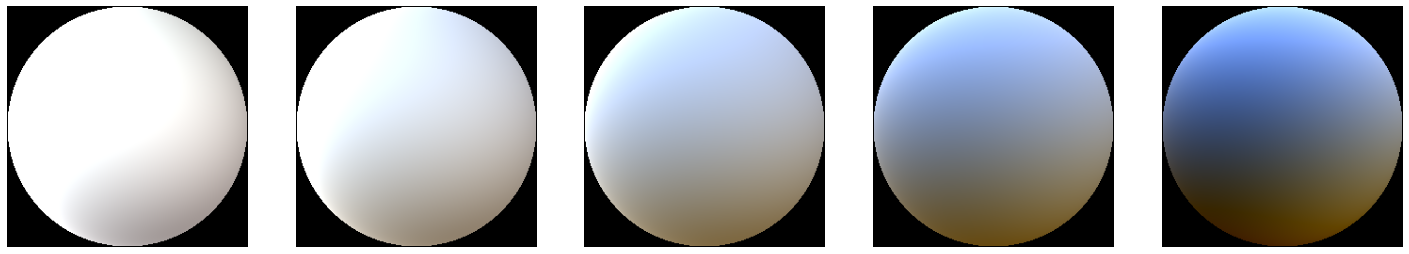

1.1544397
-0.120352164
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


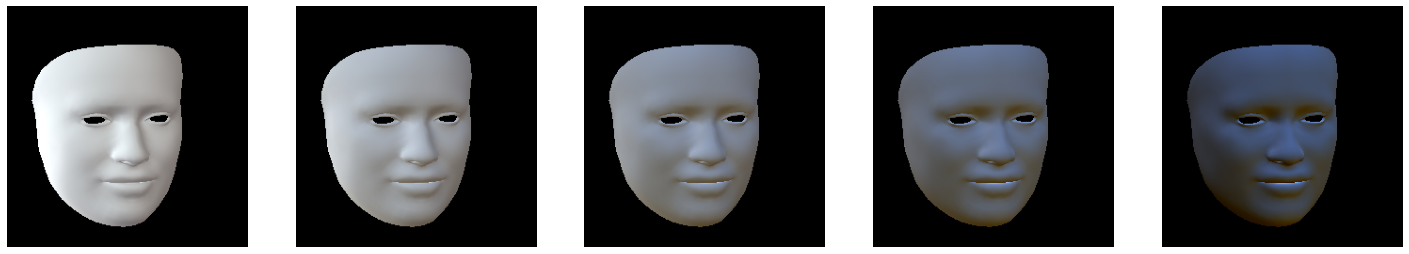

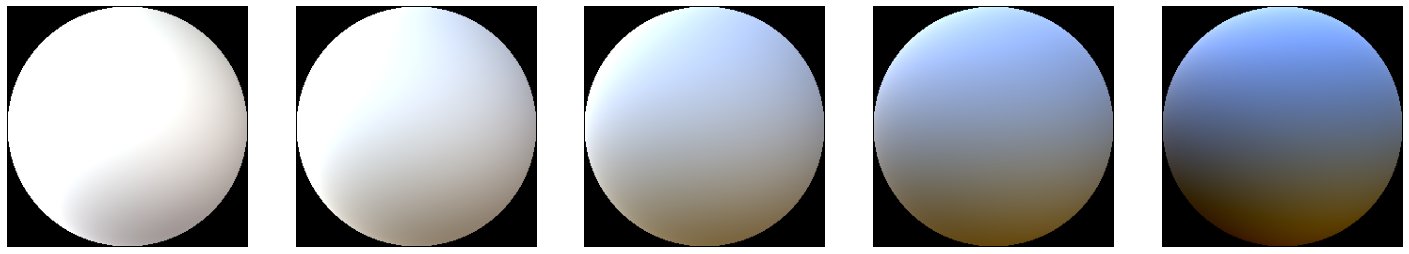

1.1544397
-0.13187869
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


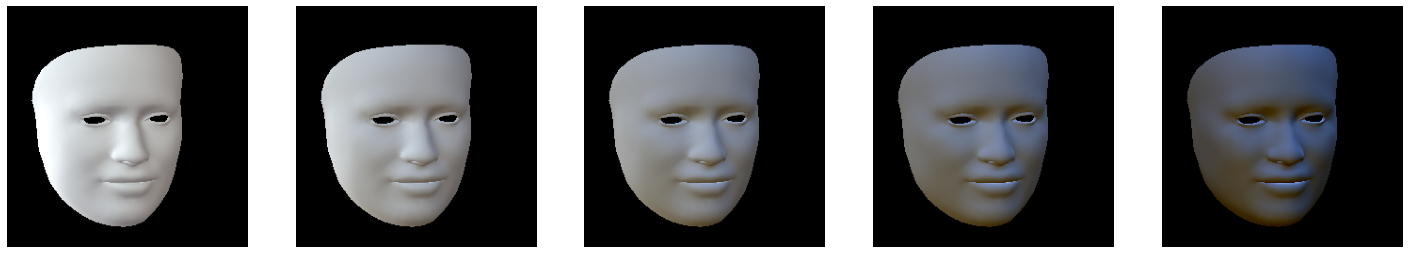

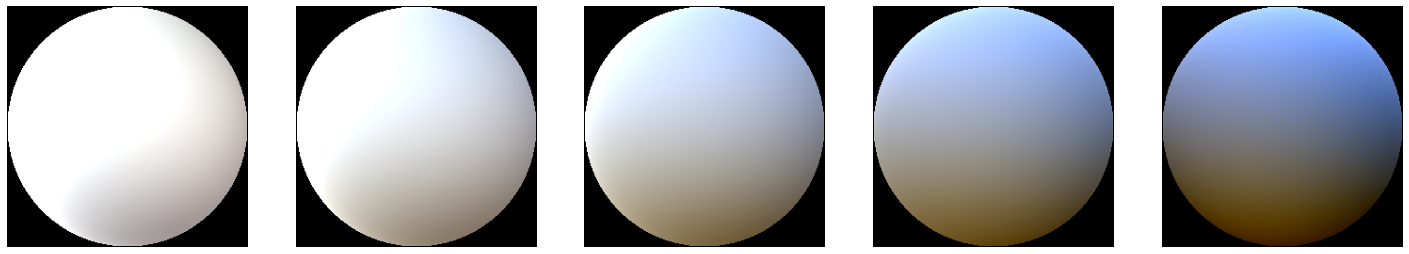

1.1544397
-0.14342952
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


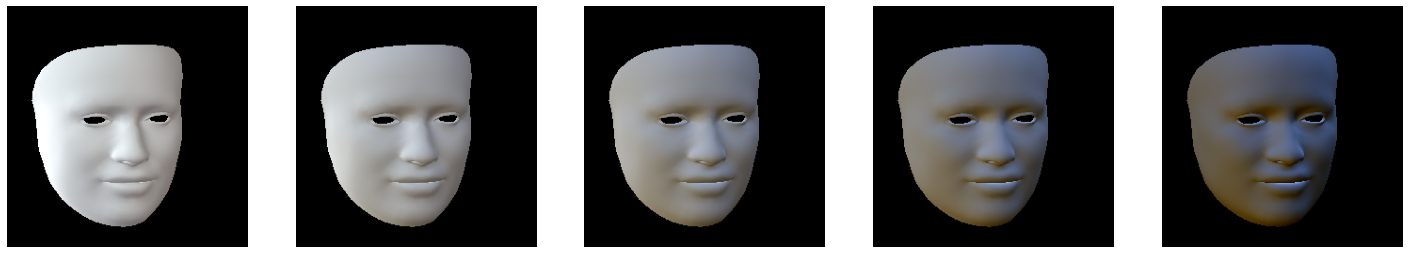

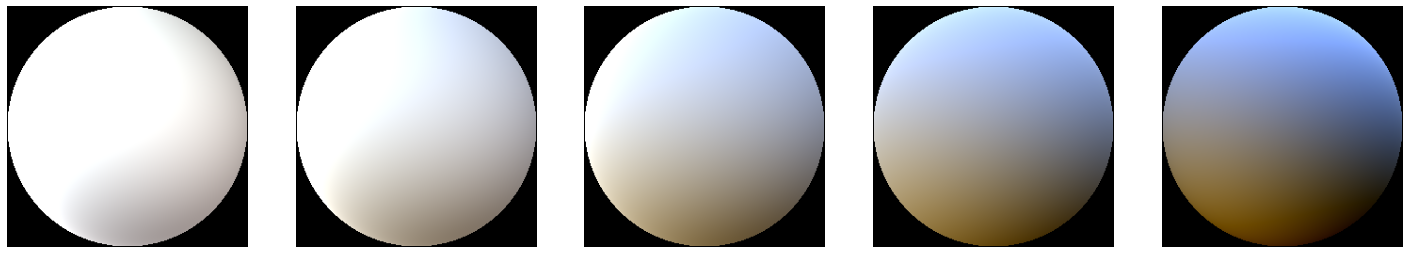

1.1544397
-0.13706388


In [17]:
ggez_sh = np.load('./difareli_test/ggez_png.npy')
print(ggez_sh[0])
# assert False

for i in range(ggez_sh.shape[0]):
    render(ggez_sh[i].flatten()[None, ...], f'roll_{i}')

[[[ 0.22937769  0.25632477  0.3411083 ]
  [-0.04451907 -0.03542881 -0.01365438]
  [ 0.06260963  0.10424671  0.21269385]
  [-0.02101421 -0.02318265 -0.01625202]
  [ 0.06540306  0.06128018  0.04812097]
  [-0.04997584 -0.04464541 -0.02866737]
  [-0.0786218  -0.08090921 -0.06995659]
  [-0.03302749 -0.03008108 -0.01989797]
  [ 0.01226678  0.00506672 -0.00369424]]]
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


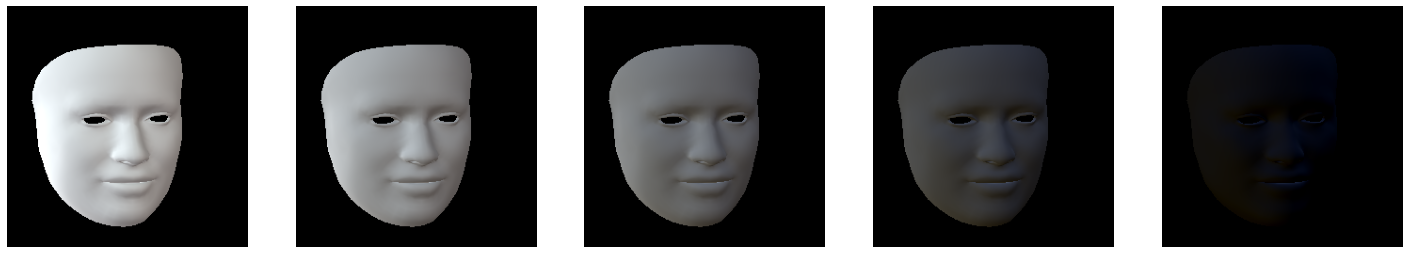

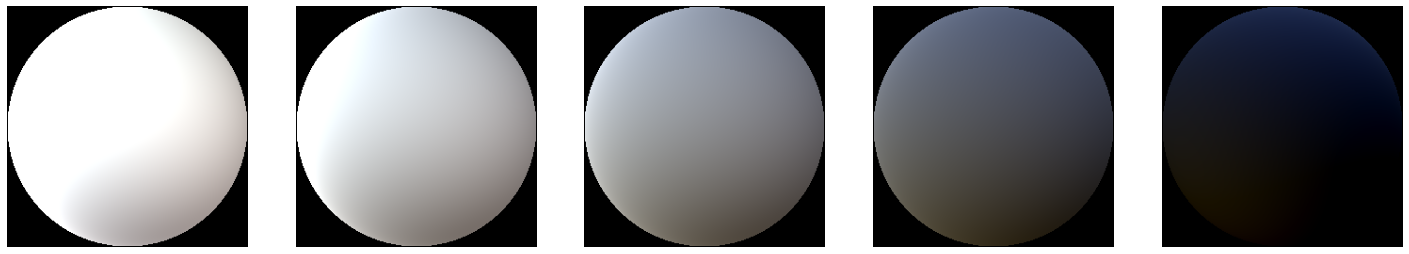

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1.1544397
-0.08388876


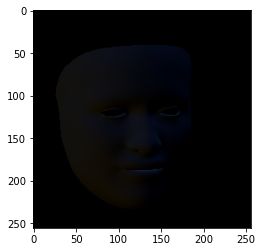

[[[ 0.56857099  0.5906201   0.64125207]
  [-0.03619881 -0.02451691 -0.00330133]
  [ 0.08049857  0.12855178  0.23144282]
  [-0.00511678 -0.006398   -0.00368681]
  [ 0.05523422  0.05037777  0.03875584]
  [-0.04991292 -0.04197581 -0.02772303]
  [-0.06691921 -0.06070255 -0.0333012 ]
  [-0.02721628 -0.0239834  -0.01572261]
  [ 0.0098657   0.00416554 -0.00221113]]]
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


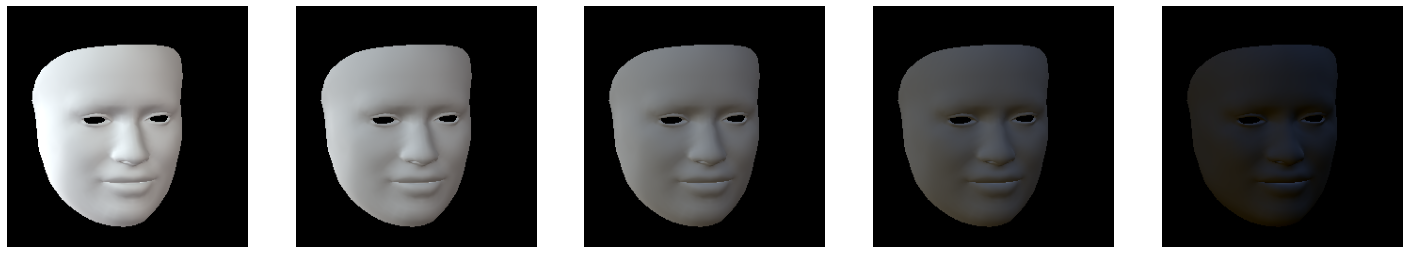

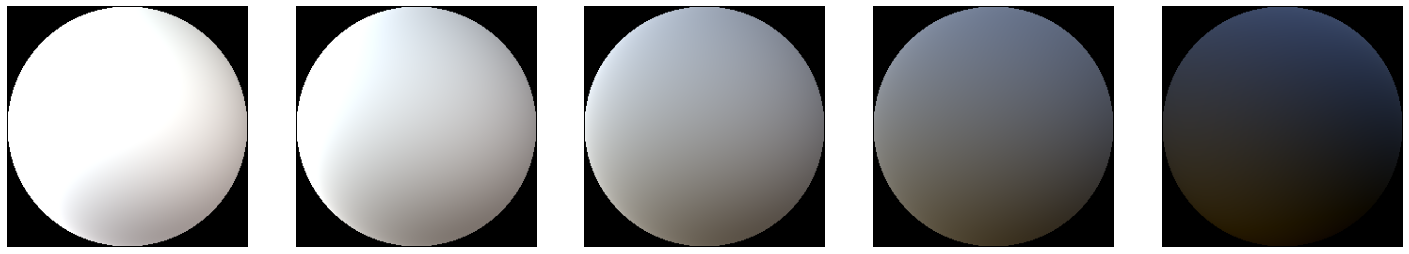

1.1544397
-0.03465484


ValueError: cannot select an axis to squeeze out which has size not equal to one

In [43]:
import numpy as np
import imp
imp.reload(misc)

class TonemapHDR(object):
    """
        Tonemap HDR image globally. First, we find alpha that maps the (max(numpy_img) * percentile) to max_mapping.
        Then, we calculate I_out = alpha * I_in ^ (1/gamma)
        input : nd.array batch of images : [H, W, C]
        output : nd.array batch of images : [H, W, C]
    """

    def __init__(self, gamma=2.4, percentile=50, max_mapping=0.5):
        self.gamma = gamma
        self.percentile = percentile
        self.max_mapping = max_mapping  # the value to which alpha will map the (max(numpy_img) * percentile) to

    def __call__(self, numpy_img, clip=True, alpha=None, gamma=True):
        if gamma:
            power_numpy_img = np.power(numpy_img, (1 / (self.gamma + 1e-10)))
        else:
            power_numpy_img = numpy_img
        non_zero = power_numpy_img > 0
        if non_zero.any():
            r_percentile = np.percentile(power_numpy_img[non_zero], self.percentile)
        else:
            r_percentile = np.percentile(power_numpy_img, self.percentile)
        if alpha is None:
            alpha = self.max_mapping / (r_percentile + 1e-10)
        tonemapped_img = np.multiply(alpha, power_numpy_img)

        if clip:
            tonemapped_img_clip = np.clip(tonemapped_img, 0, 1)

        return tonemapped_img_clip.astype('float32'), alpha, tonemapped_img

ggez_sh = np.load('./difareli_test/pure.npy')[None]
print(ggez_sh)
# assert False
# ggez = np.zeros_like(ggez_sh)
# ggez[..., 0] = ggez_sh[..., 0]
# ggez[..., 1] = ggez_sh[..., 1]
# ggez[..., 2] = ggez_sh[..., 2]

for i in range(ggez_sh.shape[0]):
    img = render(ggez_sh[i].flatten()[None, ...], f'roll_{i}')
    plt.imshow(img[-1].transpose(1, 2, 0))
    plt.show()
    
    # tmp = TonemapHDR()(np.clip(img[-1].transpose(1, 2, 0), 1e-10, None))
    # print(tmp[0].shape, tmp[0].max(), tmp[0].min())
    # plt.imshow(tmp[0])
    # plt.show()
    
    # print(tmp[-1].shape, tmp[-1].max(), tmp[-1].min())
    # plt.imshow(tmp[-1])
    # plt.show()
    
ggez_sh = np.load('./difareli_test/pure_tm.npy')[None]
print(ggez_sh)
# assert False
# ggez = np.zeros_like(ggez_sh)
# ggez[..., 0] = ggez_sh[..., 0]
# ggez[..., 1] = ggez_sh[..., 1]
# ggez[..., 2] = ggez_sh[..., 2]

for i in range(ggez_sh.shape[0]):
    render(ggez_sh[i].flatten()[None, ...], f'roll_{i}')
    cc = misc.toRGBCoeff(ggez_sh.flatten().cpu().numpy())
    print(cc.shape)
    sh_loads = misc.toRGBDeca(cc)
    sh_loads = np.array(sh_loads)[None, ...]
    render(ggez_sh[i].flatten()[None, ...], f'roll_{i}')
    

[[[ 0.56857099  0.5906201   0.64125207]
  [-0.03619881 -0.02451691 -0.00330133]
  [ 0.08049857  0.12855178  0.23144282]
  [-0.00511678 -0.006398   -0.00368681]
  [ 0.05523422  0.05037777  0.03875584]
  [-0.04991292 -0.04197581 -0.02772303]
  [-0.06691921 -0.06070255 -0.0333012 ]
  [-0.02721628 -0.0239834  -0.01572261]
  [ 0.0098657   0.00416554 -0.00221113]]]
[#] Interpolate with <function lerp at 0x7fc2cbc6a9d0>
DECA:  torch.Size([5, 3, 256, 256])
BALL:  (5, 3, 256, 256)


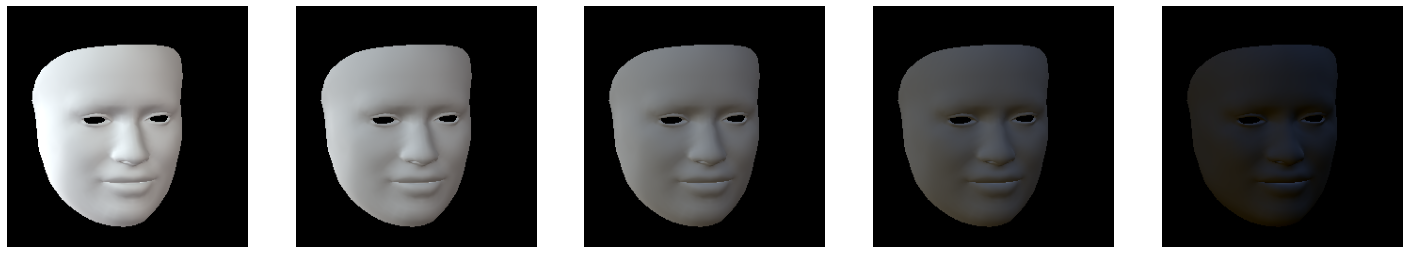

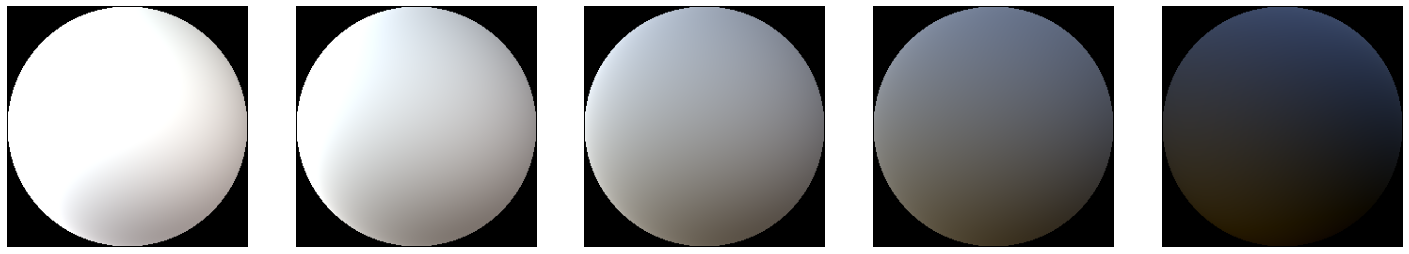

1.1544397
-0.03465484
[ 0.56857099  0.5906201   0.64125207 -0.03619881 -0.02451691 -0.00330133
  0.08049857  0.12855178  0.23144282 -0.00511678 -0.006398   -0.00368681
  0.05523422  0.05037777  0.03875584 -0.04991292 -0.04197581 -0.02772303
 -0.06691921 -0.06070255 -0.0333012  -0.02721628 -0.0239834  -0.01572261
  0.0098657   0.00416554 -0.00221113] [ 0.56857099  0.5906201   0.64125207 -0.03619881 -0.02451691 -0.00330133
  0.08049857  0.12855178  0.23144282 -0.00511678 -0.006398   -0.00368681
  0.05523422  0.05037777  0.03875584 -0.04991292 -0.04197581 -0.02772303
 -0.06691921 -0.06070255 -0.0333012  -0.02721628 -0.0239834  -0.01572261
  0.0098657   0.00416554 -0.00221113]
(1, 27) [[ 0.56857099  0.5906201   0.64125207 -0.03619881 -0.02451691 -0.00330133
   0.08049857  0.12855178  0.23144282 -0.00511678 -0.006398   -0.00368681
   0.05523422  0.05037777  0.03875584 -0.04991292 -0.04197581 -0.02772303
  -0.06691921 -0.06070255 -0.0333012  -0.02721628 -0.0239834  -0.01572261
   0.0098657  

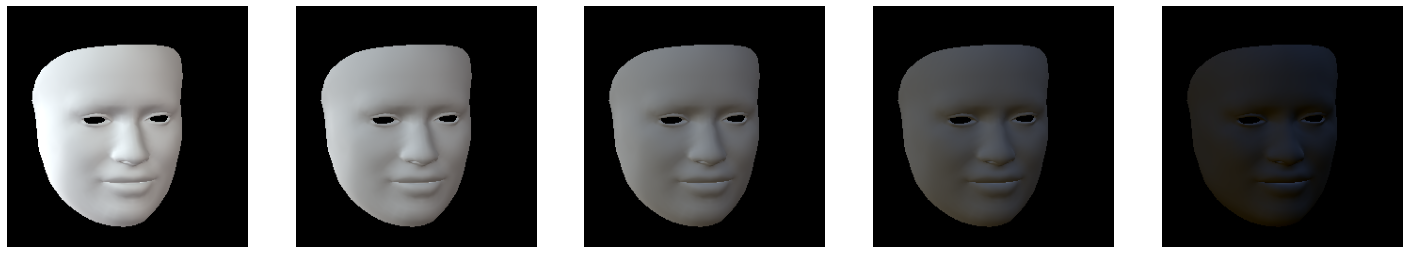

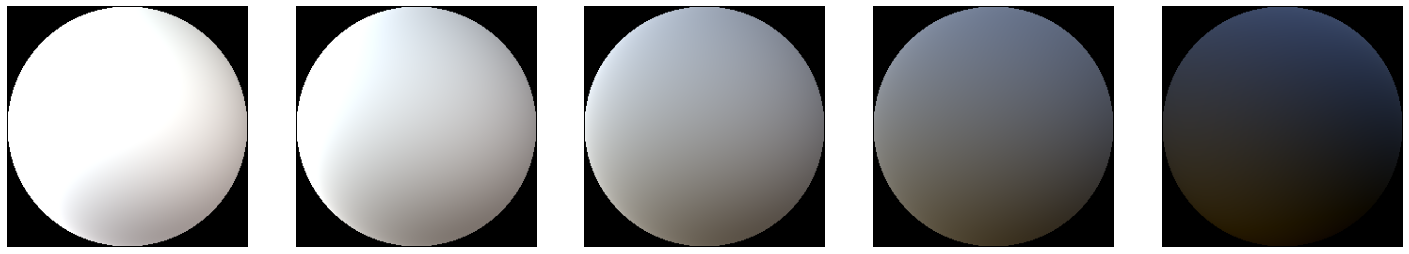

1.1544397
-0.03465484


In [49]:
ggez_sh = np.load('./difareli_test/pure_tm.npy')[None]
print(ggez_sh)
# assert False
# ggez = np.zeros_like(ggez_sh)
# ggez[..., 0] = ggez_sh[..., 0]
# ggez[..., 1] = ggez_sh[..., 1]
# ggez[..., 2] = ggez_sh[..., 2]

for i in range(ggez_sh.shape[0]):
    render(ggez_sh[i].flatten()[None, ...], f'roll_{i}')
    print(ggez_sh[i].flatten(), ggez_sh[i].flatten())
    cc = misc.toRGBCoeff(ggez_sh[i].flatten())
    # print(cc.shape)
    sh_map = misc.toRGBDeca(cc)
    sh_map = np.array(sh_map)[None, ...]
    print(sh_map.shape, sh_map)
    render(sh_map, f'roll_{i}')
    